# Pytorch Custom Dataset

## 0.Import Pytorch and Device Agnostik

In [2]:
import torch
from torch import nn

torch.__version__

'2.10.0+cu128'

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1.Import The Datasets

In [1]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [5]:
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    args:
        dir_path (str or pathlib.Path): target directory
    returns:
        number of subdirectories in dir_path,
        number of images (files) in each subdirectory, and the names of the subdirectories in dir_path
        name of each subdirencory
    """
    
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} image in '{dirpath}'")
    

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 image in 'data/pizza_steak_sushi'
There are 3 directories and 0 image in 'data/pizza_steak_sushi/train'
There are 0 directories and 72 image in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 78 image in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 image in 'data/pizza_steak_sushi/train/steak'
There are 3 directories and 0 image in 'data/pizza_steak_sushi/test'
There are 0 directories and 31 image in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 25 image in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 image in 'data/pizza_steak_sushi/test/steak'


In [7]:
# setup the training and testing paths
train_dir = image_path / "train"
test_dir = image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path: data/pizza_steak_sushi/test/pizza/1687143.jpg
Image class: pizza
Image height: 512
Image width: 512


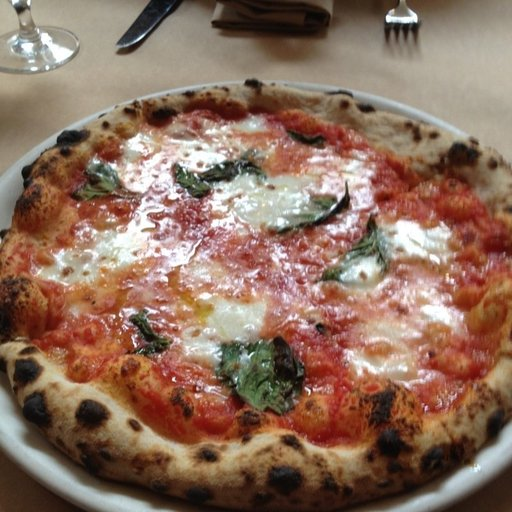

In [17]:
import random
from PIL import Image

# set seed 
random.seed(30)

# get all image paths 
image_path_list = list(image_path.glob("*/*/*.jpg"))

# get random image path
random_image_path = random.choice(image_path_list)

# get image class from path name
image_class = random_image_path.parent.stem

# open the image
img = Image.open(random_image_path)

# pring metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

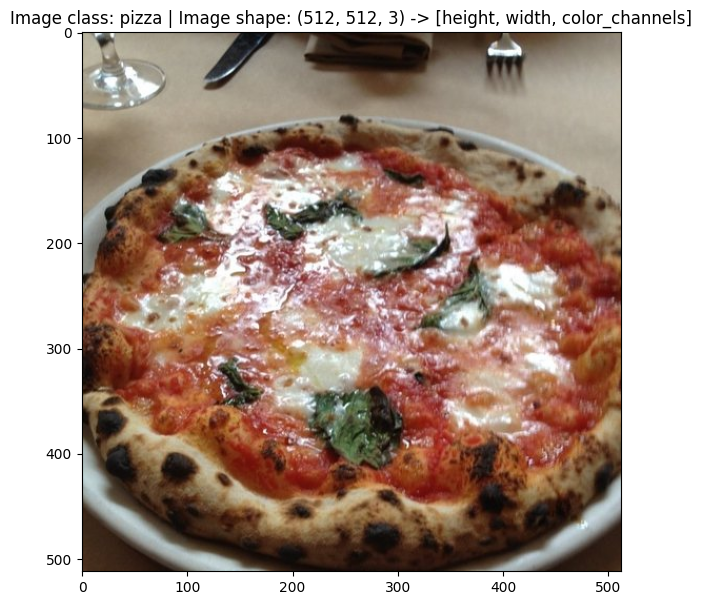

In [18]:
import numpy as np 
import matplotlib.pyplot as plt 

# turn the image into an array
img_as_array = np.asarray(img)

# plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.show()